# BB84-style QKD Pairwise-Masked Federated Learning for Radar Sensing

This notebook implements **pairwise additive masking** (Bonawitz-style) for secure aggregation in federated learning, with QKD-derived shared keys. We model QKD at the protocol level (BB84-style) to generate shared random keys; physical-layer MDI is out-of-scope. Uses U-Net radar model, spectrogram dataset, and **TVT scalability experiments** (K ∈ {3, 10, 20} clients).

In [1]:
# Install Qiskit for quantum simulation and circuit visualization (uncomment if needed)
# !pip install qiskit qiskit-aer qiskit[visualization]

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
import hashlib
import random
import pandas as pd
import os
import io
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
# === Configurable hyperparameters (TVT: K ∈ {3, 10, 20}) ===
from datetime import datetime
NUM_ROUNDS = 5           # FL rounds per experiment
NUM_CLIENTS = 3          # Legacy (TVT uses K_VALS)
LOCAL_EPOCHS = 3         # Epochs per client per round
KEY_BIT_LENGTH = 2000    # QKD raw key length
BATCH_SIZE = 4           # Training batch size
MAX_SAMPLES = 200        # Max samples for dataset (radar)
LEARNING_RATE = 1e-4     # Client optimizer learning rate
QBER_THRESHOLD = 0.08    # Abort if QBER exceeds this (TVT-aligned)
MASK_SCALE = 1e-3        # Pairwise mask magnitude (TVT-aligned)

# Results directory (TVT outputs go to outputs/radar_sensing/)
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = os.path.join("outputs", "radar_sensing")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "figures"), exist_ok=True)
print(f"RUN_ID: {RUN_ID}")
print(f"RESULTS_DIR: {RESULTS_DIR}")

RUN_ID: 20260408_105358
RESULTS_DIR: outputs/radar_sensing


## 1. U-Net Architecture (~31M parameters)

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, num_filters):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, num_filters, 3, padding=1),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_filters, num_filters, 3, padding=1),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class EncoderBlock(nn.Module):
    def __init__(self, in_ch, num_filters):
        super().__init__()
        self.conv = ConvBlock(in_ch, num_filters)
        self.pool = nn.MaxPool2d(2, 2)
    def forward(self, x):
        x = self.conv(x)
        return x, self.pool(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, num_filters):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_ch, num_filters, 2, stride=2, padding=0)
        self.conv = ConvBlock(num_filters + skip_ch, num_filters)
    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=4):
        super().__init__()
        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)
        self.bridge = ConvBlock(512, 1024)
        self.dec1 = DecoderBlock(1024, 512, 512)
        self.dec2 = DecoderBlock(512, 256, 256)
        self.dec3 = DecoderBlock(256, 128, 128)
        self.dec4 = DecoderBlock(128, 64, 64)
        self.out = nn.Conv2d(64, num_classes, 1)
    def forward(self, x):
        x1, p1 = self.enc1(x)
        x2, p2 = self.enc2(p1)
        x3, p3 = self.enc3(p2)
        x4, p4 = self.enc4(p3)
        b = self.bridge(p4)
        d1 = self.dec1(b, x4)
        d2 = self.dec2(d1, x3)
        d3 = self.dec3(d2, x2)
        d4 = self.dec4(d3, x1)
        return self.out(d4)

model = UNet(3, 4).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameters: {n_params:,} (~{n_params/1e6:.1f}M)")

U-Net parameters: 31,043,716 (~31.0M)


## 2. Data Loader (Radar MAT)

In [5]:
def load_radar_or_fallback(data_dir='data/convertedFolder', max_samples=200, img_size=64):
    """Load Radar Spectrum Sensing MAT files, or use make_moons as fallback."""
    try:
        import scipy.io
        mat_files = {int(f.replace('rcvdSpectrogram_','').replace('.mat',''))
                     for f in os.listdir(data_dir) if f.startswith('rcvdSpectrogram_') and f.endswith('.mat')}
        csv_files = {int(f.replace('trueLabels_','').replace('.csv',''))
                     for f in os.listdir(data_dir) if f.startswith('trueLabels_') and f.endswith('.csv')}
        indices = sorted(mat_files & csv_files)[:max_samples]
        conv_dict = {'Noise': 0, 'LTE': 1, 'NR': 2, 'Radar': 3}
        X, Y = [], []
        for idx in indices:
            inp = scipy.io.loadmat(os.path.join(data_dir, f'rcvdSpectrogram_{idx}.mat'))['rcvdSpectrogram']
            with open(os.path.join(data_dir, f'trueLabels_{idx}.csv')) as f:
                content = f.read()
            for k, v in conv_dict.items():
                content = content.replace(k, str(v))
            lab = pd.read_csv(io.StringIO(content), sep=',', header=None).values
            if inp.ndim == 2:
                inp = np.stack([inp]*3, axis=-1)
            X.append(inp)
            Y.append(lab)
        X = np.array(X).astype(np.float32)
        Y = np.array(Y).astype(np.int64)
        return X, Y
    except Exception as e:
        print(f"Radar data not found ({e}). Using make_moons fallback.")
        

class SpectrogramDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).long()
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = self.X[i]
        if x.dim() == 2: x = x.unsqueeze(0).repeat(3, 1, 1)
        elif x.shape[-1] == 3: x = x.permute(2, 0, 1)
        y = self.Y[i]
        if y.dim() == 3 and y.shape[0] == 1: y = y.squeeze(0)
        return x, y

X, Y = load_radar_or_fallback(max_samples=MAX_SAMPLES)
print(f"Data shape: X={X.shape}, Y={Y.shape}")

Data shape: X=(200, 256, 256, 3), Y=(200, 256, 256)


In [6]:
# Train/val split for TVT experiments
x_train, x_val, y_train, y_val = train_test_split(X, Y, test_size=0.1, random_state=42)
val_loader = DataLoader(SpectrogramDataset(x_val, y_val), batch_size=BATCH_SIZE)
print(f"Train: {len(x_train)}, Val: {len(x_val)}")

Train: 180, Val: 20


## 3. BB84-style QKD Protocol and Pairwise Masking (Correct Implementation)

In [7]:
def _privacy_amplify(sifted_key, final_len):
    sifted_len = len(sifted_key)
    sifted_bytes = bytearray()
    for i in range(0, sifted_len, 8):
        byte_val = 0
        for j in range(8):
            if i + j < sifted_len:
                byte_val = (byte_val << 1) | sifted_key[i + j]
        sifted_bytes.append(byte_val)
    sifted_bytes = bytes(sifted_bytes)
    final_key, idx = [], 0
    while len(final_key) < final_len:
        h = hashlib.sha256(sifted_bytes + idx.to_bytes(4, 'big')).digest()
        for b in h:
            for j in range(8):
                if len(final_key) < final_len:
                    final_key.append((b >> (7 - j)) & 1)
        idx += 1
    return final_key

def generate_bb84_abstraction_key(bit_length, seed=None, pa_ratio=0.8, eve_present=False, channel_noise=0.0, silent=True):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    alice_bits = [random.randint(0,1) for _ in range(bit_length)]
    alice_bases = [random.randint(0,1) for _ in range(bit_length)]
    bob_bases = [random.randint(0,1) for _ in range(bit_length)]
    eve_bases = [random.randint(0,1) for _ in range(bit_length)] if eve_present else None
    
    if eve_present:
        bob_bits = []
        for i in range(bit_length):
            eve_bit = alice_bits[i] if alice_bases[i]==eve_bases[i] else random.randint(0,1)
            bob_bit = eve_bit if bob_bases[i]==eve_bases[i] else random.randint(0,1)
            if channel_noise > 0 and random.random() < channel_noise: bob_bit = 1 - bob_bit
            bob_bits.append(bob_bit)
        sifted_idx = [i for i in range(bit_length) if alice_bases[i]==bob_bases[i]]
        alice_s = [alice_bits[i] for i in sifted_idx]
        bob_s = [bob_bits[i] for i in sifted_idx]
        sifted_len = len(alice_s)
        qber = sum(a!=b for a,b in zip(alice_s,bob_s))/sifted_len if sifted_len else 0
        final_len = max(256, int(sifted_len*pa_ratio))
        return _privacy_amplify(alice_s,final_len), _privacy_amplify(bob_s,final_len), sifted_len, final_len, qber
    
    # Qiskit BB84 quantum simulation
    if channel_noise > 0:
        nm = NoiseModel()
        nm.add_all_qubit_quantum_error(depolarizing_error(channel_noise, 1), ['x', 'h'])
        sim = AerSimulator(noise_model=nm)
    else:
        sim = AerSimulator()
    bob_bits = []
    for i in range(bit_length):
        qc = QuantumCircuit(1, 1)
        if alice_bits[i]: qc.x(0)
        if alice_bases[i]: qc.h(0)
        if bob_bases[i]: qc.h(0)
        qc.measure(0, 0)
        out = list(sim.run(qc, shots=1).result().get_counts().keys())[0]
        bob_bits.append(int(out))
    sifted_idx = [i for i in range(bit_length) if alice_bases[i]==bob_bases[i]]
    sifted_key = [bob_bits[i] for i in sifted_idx]
    alice_s = [alice_bits[i] for i in sifted_idx]
    sifted_len = len(sifted_key)
    qber = sum(a!=b for a,b in zip(alice_s,sifted_key))/sifted_len if sifted_len else 0.0
    final_len = max(256, int(sifted_len*pa_ratio))
    key_bits = _privacy_amplify(sifted_key, final_len)
    return key_bits, key_bits, sifted_len, final_len, qber

# --- Pairwise Masking (Bonawitz-style) ---
# For each client pair (i,j), derive shared key k_ij. Client i adds +m_ij for j>i, subtracts m_ji for j<i.
# Masks cancel at server when averaging. Server needs no client keys. Dropout handling not implemented.

def derive_pairwise_key(i, j, round_id, base_seed, bit_length):
    """Symmetric: k_ij == k_ji. Deterministic per (i,j,round)."""
    lo, hi = min(i, j), max(i, j)
    seed_str = f"{lo}|{hi}|{round_id}|{base_seed}"
    h = hashlib.sha256(seed_str.encode()).digest()
    bits = []
    idx = 0
    while len(bits) < bit_length:
        h = hashlib.sha256(seed_str.encode() + idx.to_bytes(4, 'big')).digest()
        for b in h:
            for k in range(8):
                if len(bits) < bit_length:
                    bits.append((b >> (7 - k)) & 1)
        idx += 1
    return bits[:bit_length]

def mask_from_bits(bits, shape, scale=MASK_SCALE, dev=None):
    """Deterministic mask from bits: +/- scale per element. Returns tensor on dev if given."""
    flat = int(np.prod(shape))
    m = np.array([scale if bits[i % len(bits)] else -scale for i in range(flat)], dtype=np.float32).reshape(shape)
    t = torch.from_numpy(m)
    return t.to(dev) if dev is not None else t

def apply_pairwise_masks(local_state_dict, client_id, round_id, num_clients, base_seed, bit_length, dev):
    """Apply pairwise additive masks. Returns masked state_dict on CPU."""
    masked = {}
    for n, p in local_state_dict.items():
        masked_p = p.detach().clone().float().to(dev)
        for j in range(num_clients):
            if j == client_id:
                continue
            bits = derive_pairwise_key(client_id, j, round_id, base_seed, bit_length)
            m = mask_from_bits(bits, p.shape, scale=MASK_SCALE, dev=dev)
            masked_p = masked_p + m if client_id < j else masked_p - m
        masked[n] = masked_p.detach().cpu()

    assert len(masked) == len(local_state_dict), "Pairwise masking did not cover all parameters"
    return masked

def average_state_dicts(lst, dev):
    return {n: torch.stack([s[n].float().to(dev) for s in lst]).mean(0) for n in lst[0].keys()}

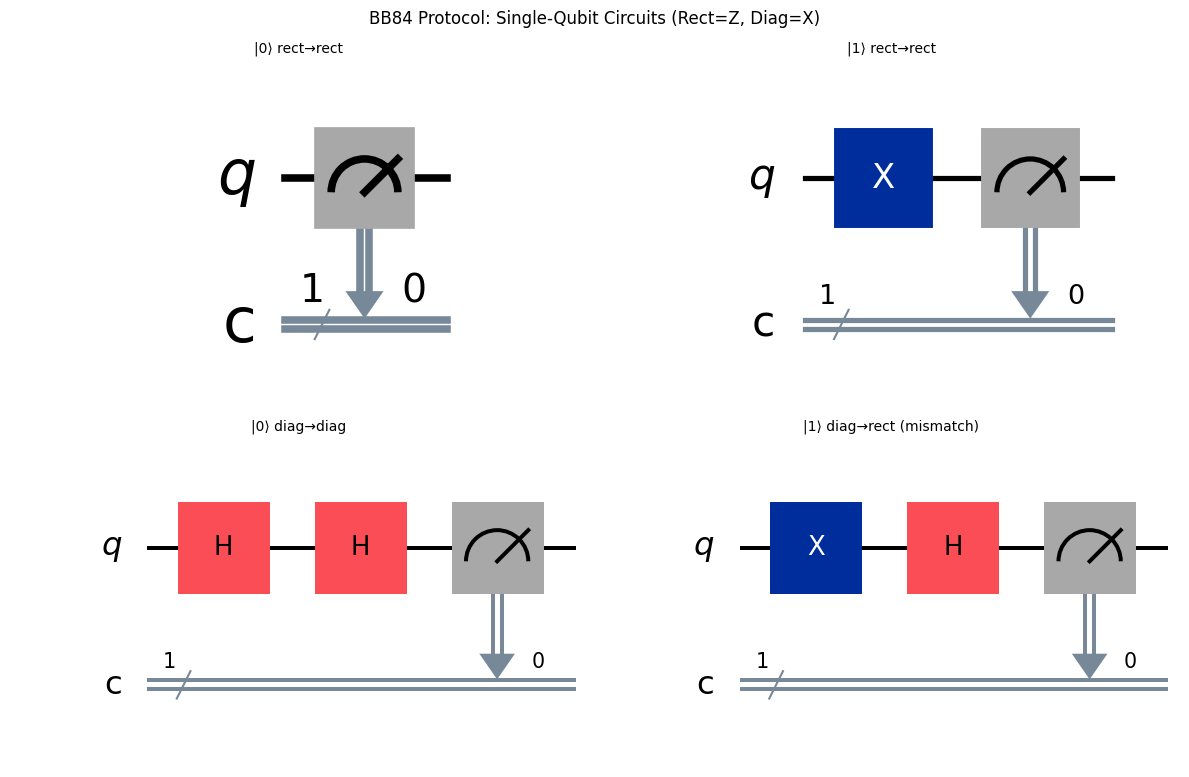

Saved: bb84_circuits.pdf


In [8]:
# BB84 Circuit Visualization (Qiskit)
def build_bb84_qubit_circuit(bit: int, alice_basis: int, bob_basis: int) -> QuantumCircuit:
    """Build a single-qubit BB84 circuit: Alice encodes |bit> in basis, Bob measures in basis."""
    qc = QuantumCircuit(1, 1, name="BB84")
    if bit == 1:
        qc.x(0)
    if alice_basis == 1:
        qc.h(0)
    if bob_basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    return qc

# Example circuits: rect=Z (0), diag=X (1)
cases = [(0, 0, 0, "|0⟩ rect→rect"), (1, 0, 0, "|1⟩ rect→rect"), (0, 1, 1, "|0⟩ diag→diag"), (1, 1, 0, "|1⟩ diag→rect (mismatch)")]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (bit, a_b, b_b, label) in zip(axes.flat, cases):
    qc = build_bb84_qubit_circuit(bit, a_b, b_b)
    try:
        circuit_drawer(qc, output="mpl", ax=ax)
    except Exception:
        ax.text(0.5, 0.5, qc.draw("text"), fontsize=7, ha="center", va="center", family="monospace")
    ax.set_title(label, fontsize=10)
plt.suptitle("BB84 Protocol: Single-Qubit Circuits (Rect=Z, Diag=X)", fontsize=12)
plt.tight_layout()
plt.savefig("bb84_circuits.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: bb84_circuits.pdf")

## 4. Training Helpers

In [9]:
def train_client(model, loader, epochs=LOCAL_EPOCHS, lr=LEARNING_RATE):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            pred = model(x)
            target = y.squeeze(1) if y.dim() > 2 else y
            loss = crit(pred, target)
            loss.backward()
            opt.step()
    return model.state_dict()

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            tgt = y.squeeze(1) if y.dim() > 2 else y
            correct += (pred == tgt).sum().item()
            total += y.numel()
    return correct / total if total else 0.0

def bb84_breakdown(bit_length, seed=None, pa_ratio=0.8):
    alice_key, bob_key, sifted, final, qber = generate_bb84_abstraction_key(bit_length, seed=seed, pa_ratio=pa_ratio, eve_present=False)
    return {"raw": bit_length, "discarded": bit_length - sifted, "sifted": sifted, "final": final}

def compute_miou(model, loader, num_classes=4):
    """Dataset-level mIoU: accumulate inter/union per class across all batches."""
    model.eval()
    inter = np.zeros(num_classes)
    union = np.zeros(num_classes)
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)
            tgt = y.squeeze(1) if y.dim() > 2 else y
            for c in range(num_classes):
                pred_c = (pred == c)
                tgt_c = (tgt == c)
                inter[c] += (pred_c & tgt_c).sum().float().item()
                union[c] += (pred_c | tgt_c).sum().float().item()
    iou_per_class = [inter[c] / union[c] for c in range(num_classes) if union[c] > 0]
    mIoU = np.mean(iou_per_class) if iou_per_class else 0.0
    assert 0 <= mIoU <= 1.0, f"mIoU {mIoU} out of [0,1]"
    return mIoU

def _flatten_sd(sd):
    return np.concatenate([v.float().cpu().numpy().flatten() for v in sd.values()]).astype(np.float32)

def compute_leakage_proxies(true_delta_sd, masked_delta_sd):
    """Cosine, Pearson, norm_ratio between true and masked deltas (attacker view)."""
    a = _flatten_sd(true_delta_sd)
    b = _flatten_sd(masked_delta_sd)
    a_norm = np.linalg.norm(a)
    b_norm = np.linalg.norm(b)
    if a_norm < 1e-12:
        return {"cosine": 0.0, "pearson": 0.0, "norm_ratio": 0.0, "sign_agreement": 0.5}
    cos = np.dot(a, b) / (a_norm * b_norm) if b_norm > 1e-12 else 0.0
    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 and np.std(a) > 1e-12 and np.std(b) > 1e-12 else 0.0
    if np.isnan(pearson): pearson = 0.0
    norm_ratio = b_norm / a_norm if a_norm > 1e-12 else 0.0
    sign_agree = np.mean(np.sign(a) == np.sign(b)) if len(a) > 0 else 0.5
    return {"cosine": float(cos), "pearson": float(pearson), "norm_ratio": float(norm_ratio), "sign_agreement": float(sign_agree)}

## 5. TVT Experiments (K sweep, plain/classical_sa/qkd_sa)

Scalability experiments with K ∈ {3, 10, 20} clients, three modes: **Plain FL** | **Classical-SA** | **QKD-SA**. Results saved to `./outputs/radar_sensing/`.

In [10]:
# TVT utilities + build_client_loaders_radar_tvt + run_experiment_tvt
import time

def get_device():
    return torch.device("mps" if torch.backends.mps.is_available() else "cpu")

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def model_size_bytes(model_or_state_dict):
    sd = model_or_state_dict if isinstance(model_or_state_dict, dict) else model_or_state_dict.state_dict()
    return sum(v.numel() * v.element_size() for v in sd.values())

def ensure_output_dirs(task="radar_sensing"):
    base = os.path.join("outputs", task)
    os.makedirs(base, exist_ok=True)
    os.makedirs(os.path.join(base, "figures"), exist_ok=True)
    return base

def save_figure(fig, name, task="radar_sensing"):
    base = ensure_output_dirs(task)
    path = os.path.join(base, "figures", name)
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.close(fig)

def partition_dataset_indices(N, K, labels=None, non_iid=True, seed=42):
    set_global_seed(seed)
    indices = np.arange(N)
    if not non_iid:
        np.random.shuffle(indices)
        shards = np.array_split(indices, min(K, N))
        return [s for s in shards if len(s) > 0]
    if labels is not None and labels.size > 0:
        flat = labels.reshape(N, -1)
        proxy = np.mean(np.abs(flat), axis=1)
    else:
        proxy = np.random.rand(N)
    sorted_idx = np.argsort(proxy)
    shards = np.array_split(sorted_idx, K)
    return [s for s in shards if len(s) > 0]

def derive_pairwise_key_classical(i, j, round_id, base_seed, bit_length):
    lo, hi = min(i, j), max(i, j)
    seed_str = f"{base_seed}|{round_id}|{lo}|{hi}"
    h = hashlib.sha256(seed_str.encode()).digest()
    bits = []
    idx = 0
    while len(bits) < bit_length:
        h = hashlib.sha256(seed_str.encode() + idx.to_bytes(4, 'big')).digest()
        for b in h:
            for k in range(8):
                if len(bits) < bit_length:
                    bits.append((b >> (7 - k)) & 1)
        idx += 1
    return bits[:bit_length]

def derive_pairwise_key_qkd(round_key_bits, i, j, bit_length):
    lo, hi = min(i, j), max(i, j)
    kb = bytearray()
    for idx in range(0, len(round_key_bits), 8):
        byte_val = 0
        for jj in range(8):
            if idx + jj < len(round_key_bits):
                byte_val = (byte_val << 1) | round_key_bits[idx + jj]
        kb.append(byte_val)
    seed_str = f"{lo}|{hi}"
    h = hashlib.sha256(bytes(kb) + seed_str.encode()).digest()
    bits = []
    idx = 0
    while len(bits) < bit_length:
        h = hashlib.sha256(bytes(kb) + seed_str.encode() + idx.to_bytes(4, 'big')).digest()
        for b in h:
            for k in range(8):
                if len(bits) < bit_length:
                    bits.append((b >> (7 - k)) & 1)
        idx += 1
    return bits[:bit_length]

def apply_pairwise_masks_tvt(local_state_dict, client_id, round_id, num_clients, base_seed, bit_length, dev,
                             key_source="classical", round_key_bits=None):
    def get_bits(j):
        if key_source == "classical":
            return derive_pairwise_key_classical(client_id, j, round_id, base_seed, bit_length)
        if key_source == "qkd":
            assert round_key_bits is not None, "QKD mode requires round_key_bits"
            return derive_pairwise_key_qkd(round_key_bits, client_id, j, bit_length)
        raise ValueError(f"key_source must be 'classical' or 'qkd', got {key_source}")
    masked = {}
    for n, p in local_state_dict.items():
        masked_p = p.detach().clone().float().to(dev)
        for j in range(num_clients):
            if j == client_id:
                continue
            bits = get_bits(j)
            m = mask_from_bits(bits, p.shape, scale=MASK_SCALE, dev=dev)
            masked_p = masked_p + m if client_id < j else masked_p - m
        masked[n] = masked_p.detach().cpu()
    assert len(masked) == len(local_state_dict), "Pairwise masking did not cover all parameters"
    return masked

def build_client_loaders_radar_tvt(x_train, y_train, K, non_iid=True, seed=42):
    N = len(x_train)
    shards = partition_dataset_indices(N, K, labels=y_train, non_iid=non_iid, seed=seed)
    loaders = []
    for shard_idx in shards:
        if len(shard_idx) == 0:
            continue
        subset_X = x_train[shard_idx]
        subset_Y = y_train[shard_idx]
        ds = SpectrogramDataset(subset_X, subset_Y)
        dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
        loaders.append(dl)
    return loaders[:K]

def run_experiment_tvt(mode, K, R, E, client_data, val_loader,
                       key_bits=KEY_BIT_LENGTH, base_seed=123, dev=None):
    dev = dev or get_device()
    global_model = UNet(3, 4).to(dev)
    model_bytes = model_size_bytes(global_model)
    bytes_downlink = model_bytes
    round_acc, round_miou_list = [], []
    round_metrics = []
    qber_hist, abort_count = [], 0
    had_abort = False
    for r in tqdm(range(R), desc=f"Round ({mode}, K={K})", leave=False):
        t_round_start = time.perf_counter()
        round_key_bits = None
        t_keygen = 0.0
        qber = 0.0
        if mode == "qkd_sa":
            t0 = time.perf_counter()
            alice_key, bob_key, sifted, final_len, qber = generate_bb84_abstraction_key(
                bit_length=key_bits, seed=r * 42 + base_seed, eve_present=False,
                channel_noise=0.0, silent=True)
            t_keygen = time.perf_counter() - t0
            round_key_bits = alice_key
            qber_hist.append(qber)
            if qber >= QBER_THRESHOLD:
                abort_count += 1
                had_abort = True
                acc = evaluate(global_model, val_loader)
                miou = compute_miou(global_model, val_loader)
                t_round_end = time.perf_counter()
                round_acc.append(acc)
                round_miou_list.append(miou)
                round_metrics.append({
                    "round": r, "acc": acc, "mIoU": miou,
                    "bytes_downlink": bytes_downlink, "bytes_uplink_total": 0,
                    "masking_time_per_client": 0, "keygen_time_per_client": t_keygen / K,
                    "round_wall_time": t_round_end - t_round_start,
                    "status": "ABORTED", "qber": qber,
                })
                continue
        client_states = []
        bytes_uplink_total = 0
        masking_times = []
        for c in range(K):
            cm = UNet(3, 4).to(dev)
            cm.load_state_dict(global_model.state_dict())
            local_sd_cpu = train_client(cm, client_data[c], epochs=E)
            if mode == "plain":
                client_states.append(local_sd_cpu)
                bytes_uplink_total += model_size_bytes(local_sd_cpu)
                masking_times.append(0.0)
            else:
                t_mask = time.perf_counter()
                masked = apply_pairwise_masks_tvt(
                    local_sd_cpu, c, r, K, base_seed, key_bits, dev,
                    key_source="classical" if mode == "classical_sa" else "qkd",
                    round_key_bits=round_key_bits)
                masking_times.append(time.perf_counter() - t_mask)
                client_states.append(masked)
                bytes_uplink_total += model_size_bytes(masked)
        avg = average_state_dicts(client_states, dev)
        global_model.load_state_dict(avg)
        acc = evaluate(global_model, val_loader)
        miou = compute_miou(global_model, val_loader)
        t_round_end = time.perf_counter()
        round_acc.append(acc)
        round_miou_list.append(miou)
        round_metrics.append({
            "round": r, "acc": acc, "mIoU": miou,
            "bytes_downlink": bytes_downlink, "bytes_uplink_total": bytes_uplink_total,
            "masking_time_per_client": np.mean(masking_times),
            "keygen_time_per_client": t_keygen / K if mode == "qkd_sa" else 0.0,
            "round_wall_time": t_round_end - t_round_start,
            "status": "RECOVERED" if had_abort else "SECURE",
            "qber": qber,
        })
    return {
        "round_acc": round_acc, "round_miou": round_miou_list,
        "round_metrics": round_metrics,
        "model_bytes": model_bytes,
        "abort_count": abort_count, "qber_history": qber_hist,
    }

In [ ]:
# TVT Experiment Runner: K in {3, 10, 20}, modes: plain, classical_sa, qkd_sa

set_global_seed(42)
TASK = "radar_sensing"
K_VALS = [3, 10, 20]
MODES = ["plain", "classical_sa", "qkd_sa"]
R, E = 5, 3  # rounds, local epochs

all_results = []
full_results = {}  # (K, mode) -> res for plotting
for K in K_VALS:
    client_loaders_k = build_client_loaders_radar_tvt(x_train, y_train, K, non_iid=True, seed=42)
    if len(client_loaders_k) < K:
        print(f"Warning: K={K} but got {len(client_loaders_k)} clients; skipping")
        continue
    for mode in MODES:
        print(f"Running K={K} mode={mode}...")
        res = run_experiment_tvt(mode, K, R, E, client_loaders_k, val_loader)
        full_results[(K, mode)] = res
        for rr in res["round_metrics"]:
            all_results.append({
                "task": TASK, "K": K, "mode": mode,
                "round": rr["round"], "acc": rr["acc"], "mIoU": rr["mIoU"],
                "bytes_downlink": rr["bytes_downlink"], "bytes_uplink_total": rr["bytes_uplink_total"],
                "masking_time": rr["masking_time_per_client"], "keygen_time": rr["keygen_time_per_client"],
                "round_wall_time": rr["round_wall_time"], "status": rr["status"],
                "qber": rr.get("qber", np.nan),
            })

# Build summary table (one row per K, mode)
df_rounds = pd.DataFrame(all_results)
summary_rows = []
for K in K_VALS:
    for mode in MODES:
        sub = df_rounds[(df_rounds["K"] == K) & (df_rounds["mode"] == mode)]
        if len(sub) == 0:
            continue
        final = sub[sub["round"] == sub["round"].max()].iloc[0]
        summary_rows.append({
            "task": TASK, "K": K, "mode": mode,
            "final_acc": final["acc"], "final_mIoU": final["mIoU"],
            "mean_round_time": sub["round_wall_time"].mean(),
            "mean_keygen_time": sub["keygen_time"].mean(),
            "mean_mask_time": sub["masking_time"].mean(),
            "bytes_downlink": final["bytes_downlink"],
            "bytes_uplink_total": final["bytes_uplink_total"],
            "abort_rate": sub[sub["status"] == "ABORTED"].shape[0] / len(sub) if len(sub) > 0 else 0,
            "mean_QBER": sub["qber"].mean() if mode == "qkd_sa" else np.nan,
        })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string())

# Save results and plots to outputs/radar_sensing/
base = ensure_output_dirs(TASK)
df_summary.to_csv(os.path.join(base, "results_summary.csv"), index=False)
df_rounds.to_csv(os.path.join(base, "results_rounds.csv"), index=False)
with open(os.path.join(base, "results_summary.json"), "w") as f:
    f.write(df_summary.to_json(orient="records", indent=2))

# Plot: Accuracy vs round for each K (3 lines: plain, classical_sa, qkd_sa)
for K in K_VALS:
    fig, ax = plt.subplots(figsize=(6, 4))
    for mode in MODES:
        key = (K, mode)
        if key not in full_results:
            continue
        acc = full_results[key]["round_acc"]
        ax.plot(range(len(acc)), acc, label=mode, marker="o", markersize=4)
    ax.set_xlabel("Round")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Radar Sensing: K={K} clients")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_figure(fig, f"acc_vs_round_K{K}.png", TASK)

# Plot: Overhead (masking + keygen time) per round
fig2, ax2 = plt.subplots(figsize=(7, 4))
x = np.arange(len(K_VALS))
width = 0.25
for i, mode in enumerate(MODES):
    means = []
    for K in K_VALS:
        sub = df_rounds[(df_rounds["K"] == K) & (df_rounds["mode"] == mode)]
        means.append((sub["masking_time"] + sub["keygen_time"]).mean() if len(sub) > 0 else 0)
    ax2.bar(x + i * width, means, width, label=mode)
ax2.set_xticks(x + width)
ax2.set_xticklabels([f"K={k}" for k in K_VALS])
ax2.set_ylabel("Mean masking+keygen time (s)")
ax2.set_title("Overhead: masking + keygen time per round")
ax2.legend()
plt.show(fig2)
save_figure(fig2, "overhead_mask_keygen.png", TASK)

print(f"Results saved to {base}/")

Running K=3 mode=plain...


Round (plain, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Running K=3 mode=classical_sa...


Round (classical_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Running K=3 mode=qkd_sa...


Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Running K=10 mode=plain...


Round (plain, K=10):   0%|          | 0/5 [00:00<?, ?it/s]

Running K=10 mode=classical_sa...


Round (classical_sa, K=10):   0%|          | 0/5 [00:00<?, ?it/s]

In [12]:
# SECTION 7 — Publication-Ready Outputs (Plots + Tables)
# Supports K ∈ {3, 10, 20} from TVT experiments.

try:
    plt.style.use('seaborn-v0_8-paper')
except OSError:
    try:
        plt.style.use('seaborn-paper')
    except OSError:
        pass

plt.rc('text', usetex=False)
plt.rc('font', family='serif')

use_tvt = 'full_results' in dir() and full_results and 'df_summary' in dir() and df_summary is not None
print(f"use_tvt: {use_tvt}")
if use_tvt:
    K_VALS_PUB = list(df_summary["K"].unique())
    MODES_PUB = ["plain", "classical_sa", "qkd_sa"]
    mode_labels = {"plain": "Plain FL", "classical_sa": "Classical-SA", "qkd_sa": "QKD-SA"}
else:
    K_VALS_PUB = []
    MODES_PUB = []

pub_dir = os.path.join(RESULTS_DIR, "pub")
os.makedirs(pub_dir, exist_ok=True)

# --- Learning curve: Accuracy vs round (per K) ---
if use_tvt:
    for K in K_VALS_PUB:
        fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200)
        for mode in MODES_PUB:
            key = (K, mode)
            if key not in full_results:
                continue
            acc = full_results[key]["round_acc"]
            lbl = mode_labels.get(mode, mode)
            ax.plot(range(len(acc)), acc, 'o-', label=lbl, markersize=4)
        ax.set_xlabel('Round')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'Radar Sensing: K={K} clients')
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        save_figure(fig, f'radar_learning_curve_K{K}.pdf', TASK)
        plt.show()
        print(f"Saved: outputs/{TASK}/figures/radar_learning_curve_K{K}.pdf")

    # --- mIoU vs round (per K) ---
    for K in K_VALS_PUB:
        fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200)
        for mode in MODES_PUB:
            key = (K, mode)
            if key not in full_results:
                continue
            miou = full_results[key]["round_miou"]
            lbl = mode_labels.get(mode, mode)
            ax.plot(range(len(miou)), miou, 'o-', label=lbl, markersize=4)
        ax.set_xlabel('Round')
        ax.set_ylabel('mIoU')
        ax.set_title(f'Radar Sensing mIoU: K={K} clients')
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        save_figure(fig, f'radar_miou_vs_round_K{K}.pdf', TASK)
        plt.show()
        print(f"Saved: outputs/{TASK}/figures/radar_miou_vs_round_K{K}.pdf")

    # --- Overhead: masking + keygen time per K ---
    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
    x = np.arange(len(K_VALS_PUB))
    width = 0.25
    for i, mode in enumerate(MODES_PUB):
        means = []
        for K in K_VALS_PUB:
            sub = df_rounds[(df_rounds["K"] == K) & (df_rounds["mode"] == mode)]
            means.append((sub["masking_time"] + sub["keygen_time"]).mean() if len(sub) > 0 else 0)
        ax.bar(x + i * width, means, width, label=mode_labels.get(mode, mode))
    ax.set_xticks(x + width)
    ax.set_xticklabels([f"K={k}" for k in K_VALS_PUB])
    ax.set_ylabel('Mean masking+keygen time (s)')
    ax.set_title('Overhead: masking + keygen time per round')
    ax.legend()
    fig.tight_layout()
    save_figure(fig, 'radar_overhead_mask_keygen.pdf', TASK)
    plt.show()
    print(f"Saved: outputs/{TASK}/figures/radar_overhead_mask_keygen.pdf")

    # --- CSV tables ---
    base = ensure_output_dirs(TASK)
    rm_path = os.path.join(base, 'round_metrics_pub.csv')
    df_rounds.to_csv(rm_path, index=False)
    print(f"Saved: {rm_path}")

    util_path = os.path.join(base, 'table_utility_security_cost.csv')
    df_summary[["K", "mode", "final_acc", "final_mIoU", "bytes_downlink", "bytes_uplink_total"]].to_csv(util_path, index=False)
    print(f"Saved: {util_path}")

    threat_rows = []
    for K in K_VALS_PUB:
        for mode in MODES_PUB:
            sub = df_rounds[(df_rounds["K"] == K) & (df_rounds["mode"] == mode)]
            if len(sub) == 0:
                continue
            statuses = sub["status"].tolist()
            threat_rows.append({
                "K": K, "mode": mode,
                "n_rounds": len(statuses),
                "n_secure": statuses.count("SECURE"),
                "n_aborted": statuses.count("ABORTED"),
                "n_recovered": statuses.count("RECOVERED"),
            })
    threat_df = pd.DataFrame(threat_rows)
    threat_path = os.path.join(base, 'table_threat_model_outcomes.csv')
    threat_df.to_csv(threat_path, index=False)
    print(f"Saved: {threat_path}")
else:
    print("Run TVT experiments (Section 6) first to generate publication outputs.")

use_tvt: False
Run TVT experiments (Section 6) first to generate publication outputs.


  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

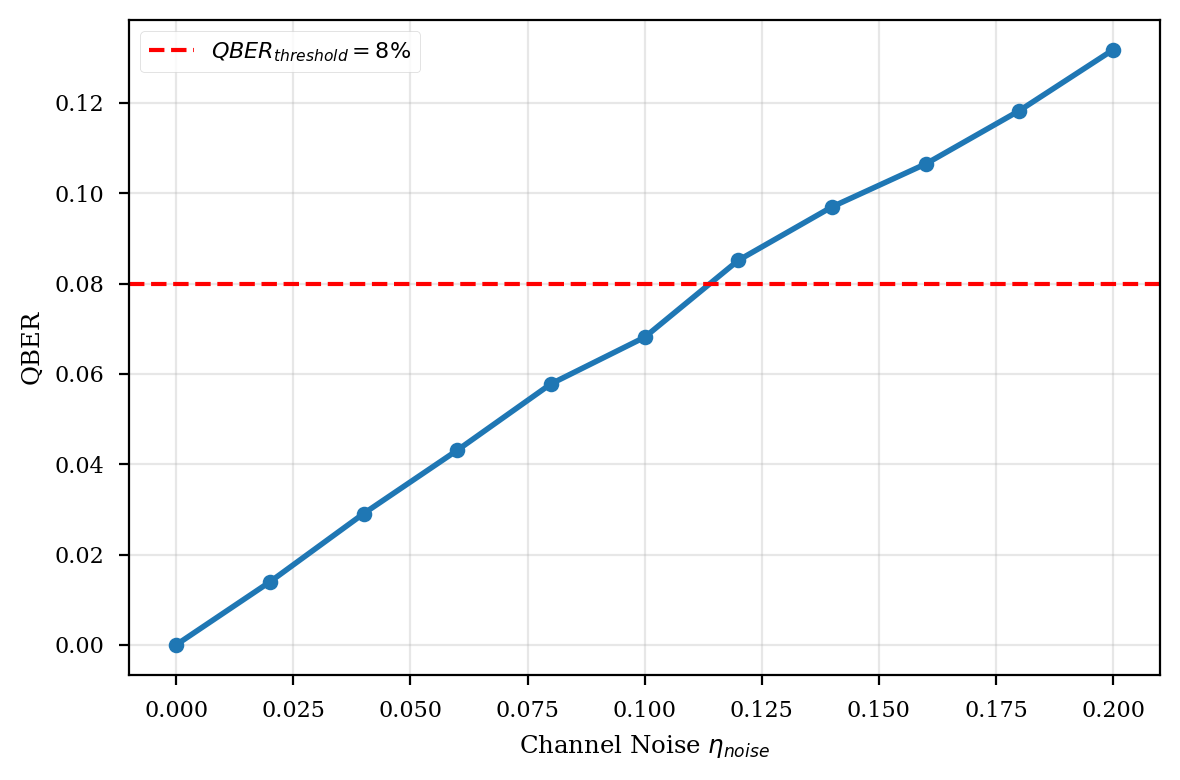

Saved: outputs/radar_sensing/figures/rad_qber_sensitivity.pdf
Saved: outputs/radar_sensing/figures/rad_qber_sensitivity.png
Saved: outputs/radar_sensing/rad_qber_sensitivity.csv


In [ ]:
# SECTION 7B — Radar QBER Sensitivity (publication figure)
# Standalone BB84/QKD noise sweep (no FL retraining required)

QBER_THRESHOLD_RADAR = 0.08
noise_levels = np.linspace(0.0, 0.20, 11)
trials_per_noise = 50

qber_rows = []
for eta in tqdm(noise_levels):
    qbers = []
    aborts = 0
    for t in tqdm(range(trials_per_noise), leave=False):
        _, _, _, _, qber = generate_bb84_abstraction_key(
            KEY_BIT_LENGTH,
            seed=1000 + t,
            pa_ratio=0.8,
            eve_present=False,
            channel_noise=float(eta),
            silent=True,
        )
        qbers.append(float(qber))
        if qber >= QBER_THRESHOLD_RADAR:
            aborts += 1
    qber_rows.append({
        "noise": float(eta),
        "mean_qber": float(np.mean(qbers)),
        "abort_count": int(aborts),
    })

rad_qber_df = pd.DataFrame(qber_rows)



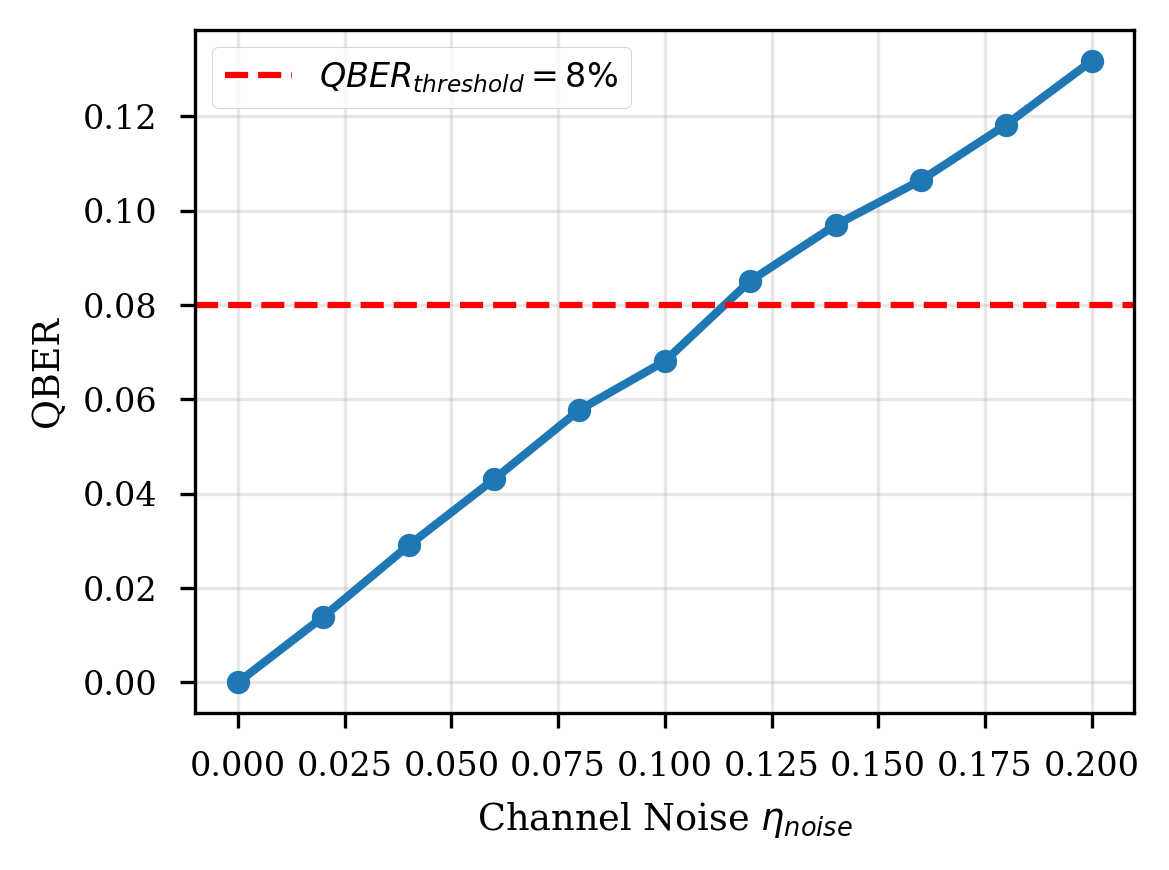

Saved: outputs/radar_sensing/figures/rad_qber_sensitivity.pdf
Saved: outputs/radar_sensing/figures/rad_qber_sensitivity.png
Saved: outputs/radar_sensing/rad_qber_sensitivity.csv


In [18]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
ax.plot(rad_qber_df["noise"], rad_qber_df["mean_qber"], marker="o", linewidth=2.0)
ax.axhline(
    y=QBER_THRESHOLD_RADAR,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=rf"$QBER_{{threshold}} = {int(QBER_THRESHOLD_RADAR*100)}\%$",
)
ax.set_xlabel(r"Channel Noise $\eta_{noise}$")
ax.set_ylabel("QBER")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
fig.tight_layout()

base = ensure_output_dirs("radar_sensing")
qber_fig_pdf = os.path.join(base, "figures", "rad_qber_sensitivity.pdf")
qber_fig_png = os.path.join(base, "figures", "rad_qber_sensitivity.png")
fig.savefig(qber_fig_pdf, bbox_inches="tight", dpi=300)
fig.savefig(qber_fig_png, bbox_inches="tight", dpi=300)
plt.show()

qber_csv = os.path.join(base, "rad_qber_sensitivity.csv")
rad_qber_df.to_csv(qber_csv, index=False)
print(f"Saved: {qber_fig_pdf}")
print(f"Saved: {qber_fig_png}")
print(f"Saved: {qber_csv}")